# 종합실습2_MNIST

## 1.환경준비

### (1) 라이브러리 로딩

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from keras.models import Sequential
from keras.layers import Dense, Flatten, Input
from keras.backend import clear_session
from keras.optimizers import Adam
from keras.datasets import mnist, fashion_mnist

* 함수 만들기

In [36]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err')
    plt.plot(history['val_loss'], label='val_err')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (2) 데이터로딩

![](https://wikidocs.net/images/page/60324/mnist.png)

In [37]:
# 케라스 데이터셋으로 부터 mnist 불러오기
(x_train, y_train), (x_val, y_val) = mnist.load_data()

In [38]:
x_train.shape, y_train.shape   # (분석단위(이미지 개수), weight, height)   #  60,000개의 28x28 크기의 이미지

((60000, 28, 28), (60000,))

In [39]:
class_names = ['0','1','2','3','4','5','6','7','8','9']

## 2 데이터 살펴보기

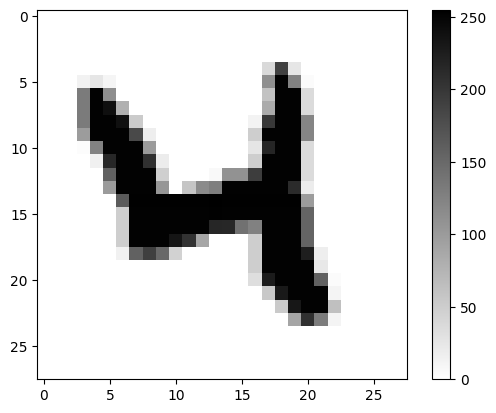

In [40]:
# 아래 숫자를 바꿔가며 화면에 그려 봅시다.
n = 20

plt.figure()
plt.imshow(x_train[n], cmap=plt.cm.binary)
plt.colorbar()
plt.show()

In [41]:
x_train[n]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  38, 190,  25,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,  13,  25,  10,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 112, 252, 125,   4,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0, 132, 252, 113,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  61, 252, 252,  36,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0, 132, 252, 240,  79,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  84, 252, 252,  36,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0, 132, 252, 252, 238,  52,   0,   0,   0,   0,   0,   0,   0,   0,  12, 198, 252, 252, 122,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,  99, 252, 252, 252, 181,  17,   0,   0,   0,   0,   0,   0,   0,  49, 252, 252, 252, 122,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   3, 125, 252, 252, 252, 100,   0,   0,   0,   0,   0,   0,   0,  26, 218, 252, 252,  36,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,  15, 216, 252, 252, 207,  19,   0,   0,   0,   0,   0,   0,  49, 252, 252, 252,  36,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0, 157, 252, 252, 252,  48,   0,   0,   0,   6, 109, 109, 194, 252, 252, 252,  36,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0, 100, 252, 252, 252, 105,   0,  58, 116, 128, 252, 252, 252, 252, 252, 212,  19,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0, 164, 253, 253, 253, 253, 253, 253, 255, 253, 253, 253, 253, 253, 253,  99,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,  49, 252, 252, 252, 252, 252, 252, 253, 252, 252, 252, 252, 252, 252, 155,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,  49, 252, 252, 252, 252, 252, 252, 217, 216, 141, 126, 252, 252, 252, 155,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,  49, 252, 252, 252, 234, 204,  89,   0,   0,   0,  49, 252, 252, 252, 155,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,  14, 158, 192, 151,  45,   0,   0,   0,   0,   0,  49, 252, 252, 252, 225,  17,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  49, 252, 252, 252, 252,  23,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  33, 228, 252, 252, 252, 157,   4,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  55, 229, 252, 252, 252,  11,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  53, 232, 252, 252,  63,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  90, 206, 131,  11,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0

In [42]:
np.set_printoptions(threshold=np.inf, linewidth=np.inf)
x_train[n]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  38, 190,  25,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,  13,  25,  10,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 112, 252, 125,   4,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0, 132, 252, 113,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  61, 252, 252,  36,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0, 132, 252, 240,  79,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  84, 252, 252,  36,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0, 132, 252, 252, 238,  52,   0,   0,   0,   0,   0,   0,   0,   0,  12, 198, 252, 252, 122,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,  99, 252, 252, 252, 181,  17,   0,   0,   0,   0,   0,   0,   0,  49, 252, 252, 252, 122,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   3, 125, 252, 252, 252, 100,   0,   0,   0,   0,   0,   0,   0,  26, 218, 252, 252,  36,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,  15, 216, 252, 252, 207,  19,   0,   0,   0,   0,   0,   0,  49, 252, 252, 252,  36,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0, 157, 252, 252, 252,  48,   0,   0,   0,   6, 109, 109, 194, 252, 252, 252,  36,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0, 100, 252, 252, 252, 105,   0,  58, 116, 128, 252, 252, 252, 252, 252, 212,  19,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0, 164, 253, 253, 253, 253, 253, 253, 255, 253, 253, 253, 253, 253, 253,  99,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,  49, 252, 252, 252, 252, 252, 252, 253, 252, 252, 252, 252, 252, 252, 155,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,  49, 252, 252, 252, 252, 252, 252, 217, 216, 141, 126, 252, 252, 252, 155,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,  49, 252, 252, 252, 234, 204,  89,   0,   0,   0,  49, 252, 252, 252, 155,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,  14, 158, 192, 151,  45,   0,   0,   0,   0,   0,  49, 252, 252, 252, 225,  17,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  49, 252, 252, 252, 252,  23,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  33, 228, 252, 252, 252, 157,   4,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  55, 229, 252, 252, 252,  11,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  53, 232, 252, 252,  63,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  90, 206, 131,  11,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0

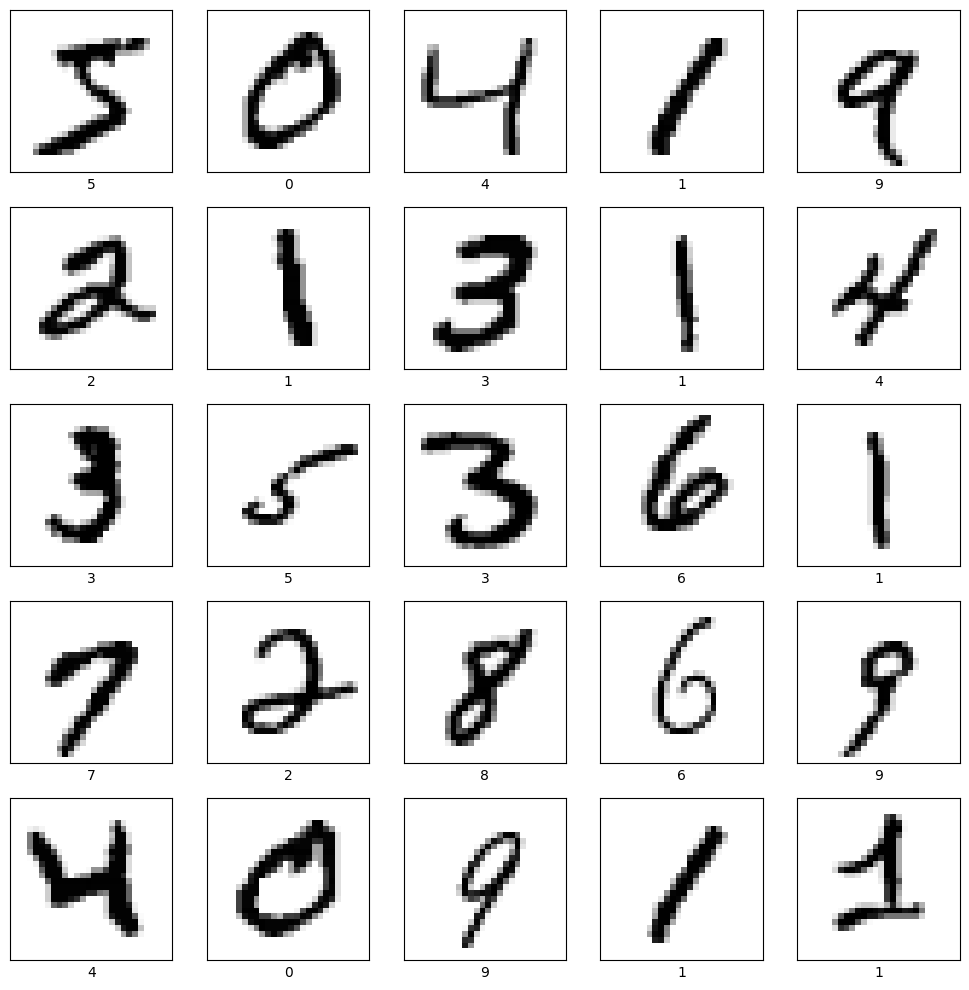

In [43]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.tight_layout()
plt.show()

## 3.데이터 준비

### (1) 데이터 2차원으로 펼치기

In [44]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape  # (60000, 28, 28)을 (60000, 784)로 만들어주고 싶은 것. 28*28 = 784

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [45]:
a = np.array([[1,2,3],[4,5,6]])
a, a.shape

(array([[1, 2, 3],
        [4, 5, 6]]),
 (2, 3))

In [46]:
#
print(a.reshape(3,2))
print(a.reshape(6,1))
print(a.reshape(6, -1))


[[1 2]
 [3 4]
 [5 6]]
[[1]
 [2]
 [3]
 [4]
 [5]
 [6]]
[[1]
 [2]
 [3]
 [4]
 [5]
 [6]]


In [47]:
# 이미지를 펼치기  -> shape가 변함.
x_train = x_train.reshape(60000, -1)
x_val = x_val.reshape(10000, -1)

In [48]:
x_train.shape, x_val.shape

((60000, 784), (10000, 784))

### (2) Scaling : Min-Max
* 0-255 값으로 되어 있는 데이터를 0-1사이 값으로 변환
* x_train, x_test를 그냥 255로 나누면 됨

In [49]:
x_train = x_train / 255.
x_val = x_val / 255.

## 4.모델링

In [50]:
nfeatures = x_train.shape[1]
nfeatures

784

In [51]:
clear_session()

# 아래 주석 코드랑 똑같은 코드이다.
model = Sequential([Dense(10, input_shape = (nfeatures,), activation = 'softmax')])
# model = Sequential([Input(shape = (nfeatures,)),
                    # Dense(10, activation = 'softmax')])

model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │           7,850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
model.compile(optimizer=Adam(learning_rate=0.001), loss= 'sparse_categorical_crossentropy' )

history = model.fit(x_train, y_train, epochs = 10, validation_split=0.2).history

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.7895 - val_loss: 0.3179
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3238 - val_loss: 0.2870
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2948 - val_loss: 0.2756
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2827 - val_loss: 0.2714
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2714 - val_loss: 0.2688
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2615 - val_loss: 0.2633
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2568 - val_loss: 0.2651
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2585 - val_loss: 0.2621
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.2585 - val_loss: 0.2603
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2506 - val_loss: 0.2611


* 학습결과 그래프

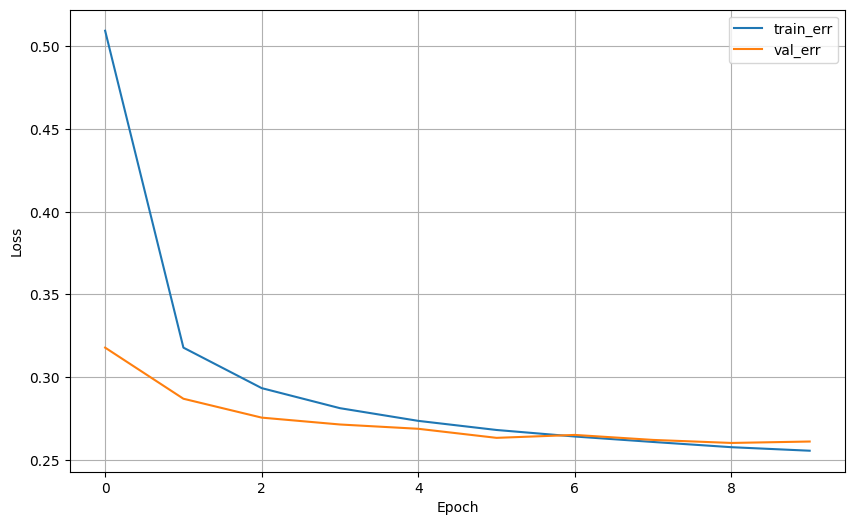

In [53]:
dl_history_plot(history)

* 예측 및 평가

In [54]:
pred = model.predict(x_val) # 스케일링 된 데이터여서 소수점으로 나온다.
pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[8.3457076e-07, 7.0388595e-12, 4.2089077e-06, 4.2000450e-03, 2.5497016e-07, 9.6124995e-06, 3.9336720e-12, 9.9544615e-01, 1.0248605e-05, 3.2872113e-04],
       [9.6567688e-05, 1.8636012e-05, 9.9297190e-01, 7.8123056e-05, 2.0511489e-14, 5.8766216e-04, 6.1971224e-03, 1.0270738e-17, 4.9967148e-05, 3.4850778e-14],
       [1.6137726e-06, 9.8092860e-01, 1.1227059e-02, 2.0855996e-03, 1.3101086e-04, 5.0792523e-04, 7.4469595e-04, 5.1442999e-04, 3.6279010e-03, 2.3125375e-04],
       [9.9970621e-01, 4.8567431e-11, 7.1459130e-05, 5.5284117e-06, 4.9870835e-08, 4.7761470e-05, 1.2314621e-04, 1.7642464e-05, 1.5199197e-05, 1.2937793e-05],
       [3.5221307e-04, 3.2043454e-07, 2.3765361e-03, 2.7552649e-05, 9.6198291e-01, 5.3235635e-05, 1.7157517e-03, 2.6523026e-03, 5.7520075e-03, 2.5087286e-02]], dtype=float32)

In [55]:
pred_1 = pred.argmax(axis=1)
pred_1[:5]

array([7, 2, 1, 0, 4])

In [56]:
print(confusion_matrix(y_val, pred_1))
print(classification_report(y_val, pred_1))

[[ 959    0    1    2    0    5    9    2    2    0]
 [   0 1115    3    2    0    1    4    2    8    0]
 [   3   11  919   19    7    3   12    9   46    3]
 [   2    0   19  920    0   17    2   13   29    8]
 [   1    1    7    1  911    0    9    7   11   34]
 [   9    3    3   40    7  757   14    9   43    7]
 [  10    3    7    1    7    7  918    2    3    0]
 [   1    6   22    7    7    0    0  955    2   28]
 [   4    8    6   17    7   16    9   12  891    4]
 [   9    7    1    9   26    4    0   31   11  911]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.97      0.98      0.97      1135
           2       0.93      0.89      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.93      0.93       982
           5       0.93      0.85      0.89       892
           6       0.94      0.96      0.95       958
           7       0.92      0.93   

## 5.실습

* 히든레이어를 추가하여 모델을 2가지 이상 만들고 성능을 비교해 봅시다.
* 성능에 영향을 주는 요인은
    * 히든레이어 수
    * 노드수
    * epochs 수 (10~20 사이에서 정하세요)
    * learning_rate

### (1) 모델1

 - Reaky ReLU 사용

In [59]:
# 모델구조

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import LeakyReLU

model = Sequential([
    Input(shape=(nfeatures, )),
    Dense(256),
    LeakyReLU(alpha=0.01),  # Leaky ReLU 사용
    Dense(128),
    LeakyReLU(alpha=0.01),
    Dense(64),
    LeakyReLU(alpha=0.01),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [61]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_4 (LeakyReLU)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_5 (LeakyReLU)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 728,288 (2.78 MB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 485,526 (1.85 MB)

In [60]:
# 컴파일, 학습
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=20, validation_split=0.2)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8805 - loss: 0.4053 - val_accuracy: 0.9595 - val_loss: 0.1355
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9686 - loss: 0.0974 - val_accuracy: 0.9699 - val_loss: 0.0972
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9793 - loss: 0.0650 - val_accuracy: 0.9698 - val_loss: 0.1070
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9843 - loss: 0.0504 - val_accuracy: 0.9708 - val_loss: 0.1033
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9868 - loss: 0.0385 - val_accuracy: 0.9747 - val_loss: 0.0936
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9895 - loss: 0.0315 - val_accuracy: 0.9700 - val_loss: 0.1104
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9917 - loss: 0.0276 - val_accuracy: 0.9756 - val_loss: 0.1050
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9913 - loss: 0.0265 - 

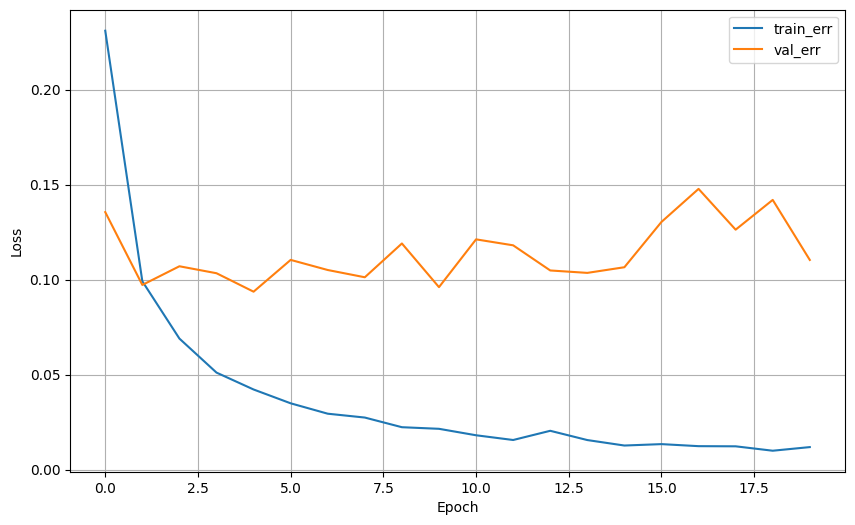

In [63]:
# 학습 곡선
dl_history_plot(history.history)

In [64]:
# 예측
pred = model.predict(x_val)
pred_1 = pred.argmax(axis=1)  # 다중분류는 argmax

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [66]:
# 평가
print(confusion_matrix(y_val, pred_1))
print(classification_report(y_val, pred_1))

[[ 972    1    0    0    1    1    3    0    1    1]
 [   0 1122    0    3    0    2    2    0    6    0]
 [   3    0 1005    7    3    0    2    4    7    1]
 [   2    0    0  988    1    9    0    5    3    2]
 [   0    1    1    0  964    0    3    2    1   10]
 [   2    0    0    4    1  874    7    0    3    1]
 [   3    3    0    1    7    4  937    0    3    0]
 [   0    2    5    3    1    1    0 1006    2    8]
 [   1    0    4    4    4    4    2    3  949    3]
 [   2    2    0    2    6    5    0    2    3  987]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.97      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.97      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98   

### (2) 모델2

In [68]:
model = Sequential([
    Input(shape=(nfeatures, )),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])


In [69]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 570,602 (2.18 MB)

 Trainable params: 570,602 (2.18 MB)

 Non-trainable params: 0 (0.00 B)

In [70]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=20, validation_split=0.2)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8743 - loss: 0.4072 - val_accuracy: 0.9588 - val_loss: 0.1378
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9694 - loss: 0.0994 - val_accuracy: 0.9691 - val_loss: 0.1085
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9785 - loss: 0.0671 - val_accuracy: 0.9703 - val_loss: 0.1076
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9843 - loss: 0.0505 - val_accuracy: 0.9688 - val_loss: 0.1170
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9868 - loss: 0.0407 - val_accuracy: 0.9771 - val_loss: 0.0900
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9889 - loss: 0.0334 - val_accuracy: 0.9761 - val_loss: 0.0997
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9912 - loss: 0.0280 - val_accuracy: 0.9740 - val_loss: 0.1178
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9926 - loss: 0.0256 -

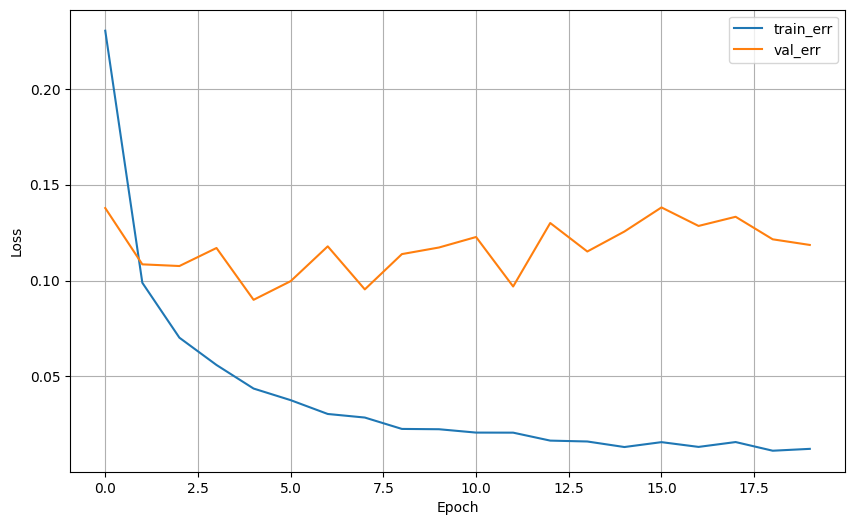

In [75]:
dl_history_plot(history.history)

In [71]:
pred=model.predict(x_val)
pred_1=pred.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [72]:
print(confusion_matrix(y_val, pred_1))
print(classification_report(y_val, pred_1))

[[ 968    1    0    0    1    1    3    3    2    1]
 [   0 1127    2    1    0    0    2    0    3    0]
 [   1    0 1018    0    3    0    0    5    4    1]
 [   1    0   11  981    0    2    0    6    7    2]
 [   0    0    1    0  967    0    4    1    0    9]
 [   2    0    1   10    2  862    3    0    7    5]
 [   4    3    0    0    6    4  939    0    2    0]
 [   1    4   12    1    3    0    0 1001    2    4]
 [   2    1    3    1    1    1    1    3  959    2]
 [   2    2    1    1    7    0    0   11    2  983]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.99      0.98      1032
           3       0.99      0.97      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.97      0.98       892
           6       0.99      0.98      0.98       958
           7       0.97      0.97   